In [1]:
import os
import pickle
import torch
from torch.utils.data import Dataset
import random

AA_TO_INDEX = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4,
    'G': 5, 'H': 6, 'I': 7, 'K': 8, 'L': 9,
    'M': 10, 'N': 11, 'P': 12, 'Q': 13, 'R': 14,
    'S': 15, 'T': 16, 'V': 17, 'W': 18, 'Y': 19,
    '-': 20, 'X': 20  # padding 또는 unknown
}

def random_voxel_rotate(voxel):
    # voxel: Tensor [C, D, H, W]
    if random.random() < 0.5:  # 50% 확률로 회전 적용
        axes = [(2, 3), (1, 3), (1, 2)]  # (H, W), (D, W), (D, H)
        k = random.choice([1, 2, 3])  # 실제 회전만 (0 제외)
        axis = random.choice(axes)
        voxel = torch.rot90(voxel, k=k, dims=axis)
    return voxel

def random_voxel_flip(voxel):
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[1])  # D-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[2])  # H-axis flip
    if random.random() < 0.5:
        voxel = torch.flip(voxel, dims=[3])  # W-axis flip
    return voxel

class VoxelDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, aug=False, symmetry=False):
        self.df = df.reset_index(drop=True)
        self.voxel_cache_dir = voxel_cache_dir
        self.aug = aug
        self.symmetry = symmetry

    def __len__(self):
        return len(self.df) * 2 if self.symmetry else len(self.df)

    def __getitem__(self, idx):

        if self.symmetry:
            real_idx = idx // 2
            is_reverse = idx % 2  # 0이면 정방향, 1이면 역방향
        else:
            real_idx = idx
            is_reverse = 0

        row = self.df.iloc[real_idx]
        uid = row["PDB"]
        mut_pos = row["MAPPED_PDB_POS"]
        wt = row["WT"]
        mut = row["MT"]
        label = row["DDG"]

        key = f"{uid}_{mut_pos}"
        voxel_path = os.path.join(self.voxel_cache_dir, f"{key}.pkl")

        # Load voxel
        with open(voxel_path, "rb") as f:
            data = pickle.load(f)
            feature = data["feature"]  # shape: (1, 7, 7, 7, 63)

        # Preprocess
        feature_tensor = torch.from_numpy(feature).permute(0, 4, 1, 2, 3).float().squeeze(0)  # (63, 7, 7, 7)

        if self.aug:
            feature_tensor = random_voxel_rotate(feature_tensor)
            feature_tensor = random_voxel_flip(feature_tensor)
        
        if is_reverse == 0:
            # Convert WT/Mut AA to index
            ref_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
            mut_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)
            target_label = label
        else:
            mut_idx = torch.tensor(AA_TO_INDEX.get(str(wt), 20), dtype=torch.long)
            ref_idx = torch.tensor(AA_TO_INDEX.get(str(mut), 20), dtype=torch.long)
            target_label = -label

        return feature_tensor, ref_idx, mut_idx, torch.tensor(target_label).float()
    
class MSADataset(Dataset):
    def __init__(self, df, msa_dict_path, max_depth=80, win_size=61, aug=False, symmetry=False):
        with open(msa_dict_path, "rb") as f:
            self.msa_dict = pickle.load(f)
        self.df = df
        self.max_depth = max_depth
        self.win_size = win_size
        self.half_win = win_size // 2  # 중심에서 양쪽 길이
        self.aug = aug
        self.symmetry = symmetry
        
    def __len__(self):
        return len(self.df) * 2 if self.symmetry else len(self.df)

    def __getitem__(self, idx):

        if self.symmetry:
            real_idx = idx // 2
            is_reverse = idx % 2  # 0이면 정방향, 1이면 역방향
        else:
            real_idx = idx
            is_reverse = 0

        row = self.df.iloc[real_idx]
        uid = row["PDB"]
        mut_pos = int(row["POS"]) - 1  # 1-based → 0-based
        mut = row["MT"].upper()
        label = row["DDG"]

        msa_seqs = [seq for _, seq in self.msa_dict[uid][:self.max_depth]]
        query_seq = msa_seqs[0]  # 보통 첫 줄이 ref seq

        # 변이 반영된 mut_seq 생성
        mut_seq = list(query_seq)
        if 0 <= mut_pos < len(mut_seq):
            mut_seq[mut_pos] = mut

        # --- 핵심 로직: 1, 2행 구성 ---
        if is_reverse == 0:
            # 정방향 (Mut -> WT): 기존 방식
            seqs_to_use = [mut_seq, list(query_seq)]
            target_label = label
        else:
            # 역방향 (WT -> Mut): 대칭 증강
            seqs_to_use = [list(query_seq), mut_seq]
            target_label = -label  # 라벨 부호 반전
            
        if len(msa_seqs) > 1:
            seqs_to_use += [list(seq) for seq in msa_seqs[1:self.max_depth - 2]]

        if self.aug:
            msa_part = seqs_to_use[2:]  # 변이+ref 제외
            random.shuffle(msa_part)   # 순서 섞기
            seqs_to_use = seqs_to_use[:2] + msa_part

        centered_msa = []
        for seq in seqs_to_use:
            window = []
            for i in range(self.win_size):
                seq_idx = mut_pos - self.half_win + i
                if 0 <= seq_idx < len(seq):
                    aa = seq[seq_idx]
                else:
                    aa = '-'
                window.append(AA_TO_INDEX.get(aa, 20))
            centered_msa.append(window)

        # depth padding
        while len(centered_msa) < self.max_depth:
            centered_msa.append([20] * self.win_size)  # 20은 패딩 인덱스

        msa_tensor = torch.tensor(centered_msa[:self.max_depth]).long()  # [D, L]
        msa_tensor = msa_tensor.transpose(0, 1)  # [L, D]

        return {
            "msa": msa_tensor,  # [L, D]
            "label": torch.tensor(target_label).float()
        }

class MultimodalDataset(Dataset):
    def __init__(self, df, voxel_cache_dir, msa_dict_path, 
                 voxel_aug=False, msa_aug=False, max_depth=80, win_size=61, symmetry=False):
        self.df = df.reset_index(drop=True)
        self.voxel_dataset = VoxelDataset(df, voxel_cache_dir, aug=voxel_aug, symmetry=symmetry)
        self.msa_dataset = MSADataset(df, msa_dict_path, max_depth=max_depth, win_size=win_size, aug=msa_aug, symmetry=symmetry)
        self.symmetry = symmetry
        
    def __len__(self):
        return len(self.df) * 2 if self.symmetry else len(self.df)

    def __getitem__(self, idx):
        voxel_feat, ref_idx, mut_idx, label = self.voxel_dataset[idx]
        msa_data = self.msa_dataset[idx]  # returns dict with "msa", "label"
        msa_tensor = msa_data["msa"]
        
        # 라벨 일치 확인 (안전용)
        assert label == msa_data["label"], "Mismatch in label!"

        return {
            "voxel": voxel_feat,      # [63, 7, 7, 7]
            "ref_idx": ref_idx,
            "mut_idx": mut_idx,
            "msa": msa_tensor,        # [L=61, D]
            "label": label
        }

In [2]:
import torch
import torch.nn as nn

# --- Voxel (Structural) Branch Components ---

class SqueezeExcitation3D(nn.Module):
    """3D SE block for channel-wise attention in voxel space."""
    def __init__(self, in_channels, reduction=24):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool3d(1)
        self.se = nn.Sequential(
            nn.Conv3d(in_channels, in_channels // reduction, kernel_size=1),
            nn.SiLU(),
            nn.Conv3d(in_channels // reduction, in_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(self.pool(x))

class MBConv3D(nn.Module):
    """3D Inverted Residual Block (MobileNetV3 style) for efficient structural learning."""
    def __init__(self, in_ch, out_ch, expand_ratio=6, kernel_size=3, stride=1, se_reduction=16):
        super().__init__()
        mid_ch = in_ch * expand_ratio
        self.use_res_connect = (stride == 1 and in_ch == out_ch)

        self.expand = nn.Sequential(
            nn.Conv3d(in_ch, mid_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        ) if expand_ratio != 1 else nn.Identity()

        self.depthwise = nn.Sequential(
            nn.Conv3d(mid_ch, mid_ch, kernel_size=kernel_size, stride=stride,
                      padding=kernel_size//2, groups=mid_ch, bias=False),
            nn.BatchNorm3d(mid_ch),
            nn.SiLU()
        )

        self.se = SqueezeExcitation3D(mid_ch, reduction=se_reduction)
        self.project = nn.Sequential(
            nn.Conv3d(mid_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch)
        )

    def forward(self, x):
        identity = x
        out = self.project(self.se(self.depthwise(self.expand(x))))

        return out + identity if self.use_res_connect else out


class h_sigmoid(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.relu = nn.ReLU6(inplace=inplace)

    def forward(self, x):
        return self.relu(x + 3) / 6

class h_swish(nn.Module):
    def __init__(self, inplace=True):
        super().__init__()
        self.sigmoid = h_sigmoid(inplace=inplace)

    def forward(self, x):
        return x * self.sigmoid(x)

class CoordAtt3D(nn.Module):
    """3D Coordinate Attention for capturing long-range spatial dependencies along D, H, W axes."""
    def __init__(self, inp, oup, reduction=16):
        super().__init__()
        self.pool_d = nn.AdaptiveAvgPool3d((None, 1, 1))  
        self.pool_h = nn.AdaptiveAvgPool3d((1, None, 1)) 
        self.pool_w = nn.AdaptiveAvgPool3d((1, 1, None))  

        mip = max(8, inp // reduction)
        self.conv1 = nn.Conv3d(inp, mip, kernel_size=1, stride=1)
        self.bn1 = nn.BatchNorm3d(mip)
        self.act = h_swish()

        self.conv_d = nn.Conv3d(mip, oup, kernel_size=1, stride=1)
        self.conv_h = nn.Conv3d(mip, oup, kernel_size=1, stride=1)
        self.conv_w = nn.Conv3d(mip, oup, kernel_size=1, stride=1)

    def forward(self, x):
        identity = x
        B, C, D, H, W = x.size()

        # Pooling along axes
        x_d = self.pool_d(x)
        x_h = self.pool_h(x).permute(0, 1, 3, 2, 4)
        x_w = self.pool_w(x).permute(0, 1, 4, 2, 3)

        # Concatenate and encode spatial info
        y = self.act(self.bn1(self.conv1(torch.cat([x_d, x_h, x_w], dim=2))))
        y_d, y_h, y_w = torch.split(y, [D, H, W], dim=2)

        # Restore dimensions and apply sigmoid
        a_d = self.conv_d(y_d).sigmoid()
        a_h = self.conv_h(y_h.permute(0, 1, 3, 2, 4)).sigmoid()
        a_w = self.conv_w(y_w.permute(0, 1, 3, 4, 2)).sigmoid()
        
        return identity * a_d * a_h * a_w


class StructuralMutationAttention(nn.Module):
    """
    Option 2: 변이 정보(Mutation)를 Query로 하여 
    구조 피처(Voxel)의 중요한 부분을 선택적으로 강조하는 어텐션
    """
    def __init__(self, feat_dim, mut_dim):
        super().__init__()
        self.mut_to_query = nn.Linear(mut_dim, feat_dim)
        self.kv_conv = nn.Conv3d(feat_dim, feat_dim * 2, kernel_size=1)
        self.scale = feat_dim ** -0.5
        self.final_conv = nn.Conv3d(feat_dim, feat_dim, kernel_size=1)

    def forward(self, x, mut_emb):
        # x: [B, C, D, H, W] (구조 피처 맵)
        # mut_emb: [B, mut_dim] (변이 아미노산 임베딩)
        B, C, D, H, W = x.shape
        
        # 1. Query 생성: 변이 정보를 구조 피처와 같은 차원으로 매핑
        q = self.mut_to_query(mut_emb).view(B, 1, C) # [B, 1, C]
        
        # 2. Key, Value 생성: 3D 공간의 각 위치를 Key/Value로 변환
        kv = self.kv_conv(x).view(B, 2*C, -1).permute(0, 2, 1) # [B, D*H*W, 2*C]
        k, v = torch.chunk(kv, 2, dim=-1) # 각각 [B, D*H*W, C]

        # 3. Attention Score: "변이가 구조의 어느 위치와 관련 깊은가?"
        # [B, 1, C] @ [B, C, D*H*W] -> [B, 1, D*H*W]
        attn = torch.bmm(q, k.transpose(1, 2)) * self.scale
        attn = attn.softmax(dim=-1)
        
        # 4. Attention 적용
        # [B, 1, D*H*W] @ [B, D*H*W, C] -> [B, 1, C]
        out = torch.bmm(attn, v).view(B, C, 1, 1, 1)
        
        # 5. Gating: 구조 피처 맵에 어텐션 결과 반영
        return x * out.sigmoid()

class VoxelBranch(nn.Module):
    def __init__(self, in_ch=63, emb_dim=128):
        super().__init__()
        
        # 스테이지 1: 초기 구조 특징 추출
        self.stage1 = nn.Sequential(
            MBConv3D(in_ch, 32), MBConv3D(32, 48),
            MBConv3D(48, 64), MBConv3D(64, 64, stride=2) # 4x4x4 하향 샘플링
        )

        # --- [Option 2: Mid-Attention] ---
        # 64채널 시점에서 변이 정보 주입
        self.mut_mid_attn = StructuralMutationAttention(64, emb_dim // 2)
        
        # 스테이지 2: 심층 특징 추출
        self.stage2 = nn.Sequential(
            MBConv3D(64, 96), MBConv3D(96, 96),
            MBConv3D(96, 96), MBConv3D(96, 128),
            MBConv3D(128, emb_dim), MBConv3D(emb_dim, emb_dim)
        )

        self.coordatt = CoordAtt3D(emb_dim, emb_dim)
        self.pool = nn.AdaptiveAvgPool3d(1)

        # 임베딩 레이어
        self.ref_emb = nn.Embedding(21, emb_dim // 2)
        self.mut_emb = nn.Embedding(21, emb_dim // 2)
        
        # 최종 융합 헤드
        self.fusion = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.BatchNorm1d(emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, x, ref_idx, mut_idx):
        # 1. 변이 임베딩 생성
        r_emb = self.ref_emb(ref_idx)
        m_emb = self.mut_emb(mut_idx)
        mut_context = torch.cat([r_emb, m_emb], dim=1) # [B, emb_dim]

        # 2. 스테이지 1 통과 (구조 정보)
        x = self.stage1(x)

        # 3. [Option 2 적용] 변이 정보를 기반으로 구조 피처 필터링
        # m_emb (64차원)를 Query로 사용하여 64채널의 x를 Attention
        x = self.mut_mid_attn(x, m_emb)

        # 4. 스테이지 2 통과
        x = self.stage2(x)
        struct_feat = self.pool(self.coordatt(x)).flatten(1)

        # 5. 최종 결합 (Late Fusion)
        combined = torch.cat([struct_feat, mut_context], dim=1)
        return self.fusion(combined)


import torch
import torch.nn as nn
from mamba_ssm import Mamba

# --- MSA (Sequence) Branch Components ---

class MSAInputEmbedding(nn.Module):
    """
    Converts raw MSA indices into continuous embedding space.
    Input: (B, L, D) -> Output: (B, L, D, C)
    """
    def __init__(self, vocab_size=21, dim=256):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=dim)

    def forward(self, x): 
        return self.embedding(x)  


class CrossAxialMambaMSA(nn.Module):
    """
    Hybrid block processing two axes:
    1. L-axis: Sequential context via Mamba (processed in parallel for all depths).
    2. D-axis: Evolutionary context via 1D-Conv (at the center mutation position).
    """
    def __init__(self, dim):
        super().__init__()
        self.norm_L = nn.RMSNorm(dim, eps=1e-8)
        self.norm_D = nn.RMSNorm(dim, eps=1e-8)

        self.mamba_L = Mamba(d_model=dim, expand=1)
        self.conv_D = nn.Sequential(
            nn.Conv1d(dim, dim, kernel_size=5, padding=2),
            nn.SiLU(),
            nn.Conv1d(dim, dim, kernel_size=5, padding=2),
            nn.SiLU()
        )

    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2 
        
        # --- D-axis processing: 이제 모든 위치(L)에서 연산됨 ---
        res_d = self.norm_D(x).reshape(B * L, D, C).transpose(1, 2)
        d_out = self.conv_D(res_d).transpose(1, 2).view(B, L, D, C)

        # --- L-axis processing: Mamba ---
        x_l = self.norm_L(x).permute(0, 2, 1, 3).contiguous().view(B * D, L, C)
        l_out = self.mamba_L(x_l).view(B, D, L, C).permute(0, 2, 1, 3) 

        # --- Residual Connection: d_out이 이미 x와 같은 크기이므로 바로 더함 ---
        # d_full 부분을 삭제하고 d_out을 직접 더합니다.
        return x + d_out + l_out
    
class MSAEncoder(nn.Module):
    """Stack of Cross-Axial Mamba blocks for evolutionary feature extraction."""
    def __init__(self, num_layers=8, dim=256):
        super().__init__()
        self.embeddings = MSAInputEmbedding(dim=dim)
        self.blocks = nn.ModuleList([
            CrossAxialMambaMSA(dim) for _ in range(num_layers)
        ])
        self.norm_f = nn.RMSNorm(dim, eps=1e-8)

    def forward(self, x):  
        x = self.embeddings(x)  
        for block in self.blocks:
            x = block(x)
        return self.norm_f(x)  

class CenterAwarePooling(nn.Module):
    """
    Uses Multi-head Attention to aggregate global MSA context 
    using the center mutation site as the Query.
    """
    def __init__(self, dim, num_heads=8):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

        self.gate = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.SiLU(),
            nn.Linear(dim // 2, 1)
        )
        
    def forward(self, x):  # x: (B, L, D, C)
        B, L, D, C = x.shape
        center_L = L // 2

        # Query: center residue profile [B*D, 1, C]
        query = x[:, center_L].reshape(B * D, 1, C)
        # Key/Value: entire window [B*D, L, C]
        keyval = x.permute(0, 2, 1, 3).reshape(B * D, L, C)

        attn_out, _ = self.attn(query, keyval, keyval)   # (B*D, 1, C)
        
    
        # 2. 서열별 특징 추출 [B, D, C]
        per_seq_feats = attn_out.view(B, D, C)
        
        # 3. [진짜 수정 포인트] Gated Attention Pooling
        # 각 Depth 서열이 얼마나 중요한지 점수를 매김 (Softmax)
        gate_weights = self.gate(per_seq_feats) # [B, D, 1]
        gate_weights = torch.softmax(gate_weights, dim=1) # 80개 서열의 중요도 합 = 1
        
        # 가중 평균 수행 (Weighted Sum)
        pooled = torch.sum(per_seq_feats * gate_weights, dim=1) # [B, C]

        return pooled
    
class MSABranch(nn.Module):
    """Complete MSA processing branch."""
    def __init__(self, num_layers=4, dim=128):
        super().__init__()
        self.encoder = MSAEncoder(num_layers=num_layers, dim=dim)
        self.pooling = CenterAwarePooling(dim, num_heads=4)
        self.refine = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU()
        )

    def forward(self, x):  
        x = self.encoder(x)        
        x = self.pooling(x)        
        return self.refine(x)     
    
import numpy as np
import torch.nn.functional as F

# --- Main Multimodal Model ---
    
class EvoStructCLIP(nn.Module):
    """
    EvoStructCLIP: A Multimodal framework for Variant Effect Prediction.
    Integrates evolutionary information (MSA) and 3D structural context (Voxel).
    Uses Contrastive Learning (CLIP-style) and Classification.
    """
    def __init__(self, voxel_ch=63, mb_layers=12, embed_dim=128, use_concat=True):
        super().__init__()
        self.voxel_encoder = VoxelBranch(in_ch=voxel_ch, emb_dim=embed_dim)
        self.msa_encoder = MSABranch(num_layers=mb_layers, dim=embed_dim)
        self.use_concat = use_concat

        # CLIP temperature parameter
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, voxel, ref_idx, mut_idx, msa):
        # 1. Extract features from both modalities
        voxel_feat = self.voxel_encoder(voxel, ref_idx, mut_idx) # (B, 128)
        msa_feat = self.msa_encoder(msa)                       # (B, 128)

        # 2. Compute Contrastive Logits (CLIP-style)
        v_norm = F.normalize(voxel_feat, dim=-1, eps=1e-8)
        m_norm = F.normalize(msa_feat, dim=-1, eps=1e-8)

        scale = self.logit_scale.exp()
        logits_per_voxel = torch.matmul(v_norm, m_norm.t()) * scale
        logits_per_msa = logits_per_voxel.t() 

        return {
            "logits_per_msa": logits_per_msa,
            "logits_per_voxel": logits_per_voxel,
            "voxel_feat": voxel_feat,
            "msa_feat": msa_feat,
            "v_norm": v_norm,
            "m_norm": m_norm
        }

/home/kunny/miniconda3/envs/mamba_env_exp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.model_selection import KFold

df = pd.read_csv(r"/mnt/c/Users/Kunny/Documents/GitHub/CAGI/EvoStructCLIP/Stability/S2450_Final_PDB_Mapped.tsv", sep="\t", )
df

,PDB,WT,POS,MT,DDG,CVFOLD,MAPPED_PDB,MAPPED_CHAIN,MAPPED_PDB_POS,MAPPED_OFFSET
0,P03050,Q,9,G,0.22,2,1ARR,A,9,0
1,P03050,R,13,G,0.27,2,1ARR,A,13,0
2,P03050,R,16,G,-0.64,2,1ARR,A,16,0
3,P03050,E,17,G,-0.57,2,1ARR,A,17,0
4,P03050,L,19,Q,-0.90,2,1ARR,A,19,0
...,...,...,...,...,...,...,...,...,...,...
2393,P00698,W,126,Y,-1.92,0,4LYZ,A,108,18
2394,P00698,R,132,H,0.68,0,4LYZ,A,114,18
2395,P00698,G,135,A,-1.46,0,4LYZ,A,117,18
2396,P00698,Q,139,H,-0.45,0,4LYZ,A,121,18


In [4]:
# 경로 설정
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_S2450.pkl"
voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_S2450_no_PLDDT"

test_ds = MultimodalDataset(df, voxel_cache_dir, msa_dict_path, voxel_aug=False, msa_aug=False, symmetry=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)


In [ ]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import os
from tqdm import tqdm

# --- 설정 및 경로 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_tsv_path = "/mnt/c/Users/Kunny/Documents/GitHub/CAGI/EvoStructCLIP/Stability/S2450_Final_PDB_Mapped.tsv"
msa_dict_path = "/mnt/e/CAGI_data/msa_dict_S2450.pkl"
voxel_cache_dir = "/mnt/e/CAGI_data/voxel_cache_S2450_no_PLDDT"

clip_weight_path = f"/mnt/e/CAGI_data/best_clip_model_260123_epoch51.pth"


# 1. 테스트 데이터셋 로드
test_df = pd.read_csv(test_tsv_path, sep="\t")
# MultimodalDataset 클래스는 이전 코드에 정의된 것을 그대로 사용한다고 가정합니다.
test_ds = MultimodalDataset(test_df, voxel_cache_dir, msa_dict_path, symmetry=False)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=4)

# 모델 초기화 및 가중치 로드
# EvoStructCLIP 클래스 등이 정의되어 있어야 합니다.
model = EvoStructCLIP(voxel_ch=45, mb_layers=6, embed_dim=128).to(device)
model.load_state_dict(torch.load(clip_weight_path, map_location=device))
model.eval()

all_labels = []
all_voxel_feat = []
all_msa_feat = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc=f"Inference"):
        msa = batch["msa"].to(device)
        voxel = batch["voxel"].to(device)
        ref_idx = batch["ref_idx"].to(device)
        mut_idx = batch["mut_idx"].to(device)
        labels = batch["label"].to(device)

        preds = model(voxel, ref_idx, mut_idx, msa)

        all_voxel_feat.extend(preds["v_norm"].cpu().numpy())
        all_msa_feat.extend(preds["m_norm"].cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

df["msa_embedding"] = all_msa_feat
df["voxel_embedding"] = all_voxel_feat

Inference: 100%|██████████| 150/150 [00:15<00:00,  9.94it/s]


In [6]:
df

,PDB,WT,POS,MT,DDG,CVFOLD,MAPPED_PDB,MAPPED_CHAIN,MAPPED_PDB_POS,MAPPED_OFFSET,msa_embedding,voxel_embedding
0,P03050,Q,9,G,0.22,2,1ARR,A,9,0,"[0.36606196, 0.017990006, 0.017577777, -0.1036...","[0.2471049, 0.032295045, -0.1549912, -0.001009..."
1,P03050,R,13,G,0.27,2,1ARR,A,13,0,"[0.32809928, -0.0076708356, 0.08144126, -0.080...","[0.20619832, -0.10119267, 0.070997685, -0.0659..."
2,P03050,R,16,G,-0.64,2,1ARR,A,16,0,"[0.32225174, -0.0017497175, 0.07777154, -0.102...","[0.18216231, -0.11855158, 0.107223526, -0.0654..."
3,P03050,E,17,G,-0.57,2,1ARR,A,17,0,"[0.16249934, -0.03419398, 0.0053721033, -0.081...","[0.15126042, -0.12038248, 0.00033525433, -0.03..."
4,P03050,L,19,Q,-0.90,2,1ARR,A,19,0,"[-0.0017019894, 0.0421558, -0.0072082477, -0.0...","[-0.035153683, 0.0054046605, -0.0619832, -0.10..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2393,P00698,W,126,Y,-1.92,0,4LYZ,A,108,18,"[0.06439537, 0.09410209, 0.014705523, -0.11022...","[0.020326888, 0.08919836, -0.05058203, -0.1322..."
2394,P00698,R,132,H,0.68,0,4LYZ,A,114,18,"[-0.066235214, -0.0081883585, 0.18161523, 0.12...","[-0.09408306, -0.019120006, 0.1348656, 0.04728..."
2395,P00698,G,135,A,-1.46,0,4LYZ,A,117,18,"[-0.0086517725, -0.05248532, 0.044384636, 0.21...","[-0.00024676276, -0.13187999, 0.031550482, 0.1..."
2396,P00698,Q,139,H,-0.45,0,4LYZ,A,121,18,"[-0.08857494, 0.09680594, 0.020066516, -0.1036...","[-0.031195633, 0.13962674, -0.0054516545, -0.0..."


In [7]:
df["stability_proxy"] = (df["DDG"].abs() > 1.5).astype(int)

print(df["stability_proxy"].value_counts())

stability_proxy
0    1559
1     839
Name: count, dtype: int64


In [9]:
df

,PDB,WT,POS,MT,DDG,CVFOLD,MAPPED_PDB,MAPPED_CHAIN,MAPPED_PDB_POS,MAPPED_OFFSET,msa_embedding,voxel_embedding,stability_proxy
0,P03050,Q,9,G,0.22,2,1ARR,A,9,0,"[0.36606196, 0.017990006, 0.017577777, -0.1036...","[0.2471049, 0.032295045, -0.1549912, -0.001009...",0
1,P03050,R,13,G,0.27,2,1ARR,A,13,0,"[0.32809928, -0.0076708356, 0.08144126, -0.080...","[0.20619832, -0.10119267, 0.070997685, -0.0659...",0
2,P03050,R,16,G,-0.64,2,1ARR,A,16,0,"[0.32225174, -0.0017497175, 0.07777154, -0.102...","[0.18216231, -0.11855158, 0.107223526, -0.0654...",0
3,P03050,E,17,G,-0.57,2,1ARR,A,17,0,"[0.16249934, -0.03419398, 0.0053721033, -0.081...","[0.15126042, -0.12038248, 0.00033525433, -0.03...",0
4,P03050,L,19,Q,-0.90,2,1ARR,A,19,0,"[-0.0017019894, 0.0421558, -0.0072082477, -0.0...","[-0.035153683, 0.0054046605, -0.0619832, -0.10...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2393,P00698,W,126,Y,-1.92,0,4LYZ,A,108,18,"[0.06439537, 0.09410209, 0.014705523, -0.11022...","[0.020326888, 0.08919836, -0.05058203, -0.1322...",1
2394,P00698,R,132,H,0.68,0,4LYZ,A,114,18,"[-0.066235214, -0.0081883585, 0.18161523, 0.12...","[-0.09408306, -0.019120006, 0.1348656, 0.04728...",0
2395,P00698,G,135,A,-1.46,0,4LYZ,A,117,18,"[-0.0086517725, -0.05248532, 0.044384636, 0.21...","[-0.00024676276, -0.13187999, 0.031550482, 0.1...",0
2396,P00698,Q,139,H,-0.45,0,4LYZ,A,121,18,"[-0.08857494, 0.09680594, 0.020066516, -0.1036...","[-0.031195633, 0.13962674, -0.0054516545, -0.0...",0


In [15]:
X_msa = np.vstack(df["msa_embedding"].values)

/home/kunny/miniconda3/envs/mamba_env_exp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


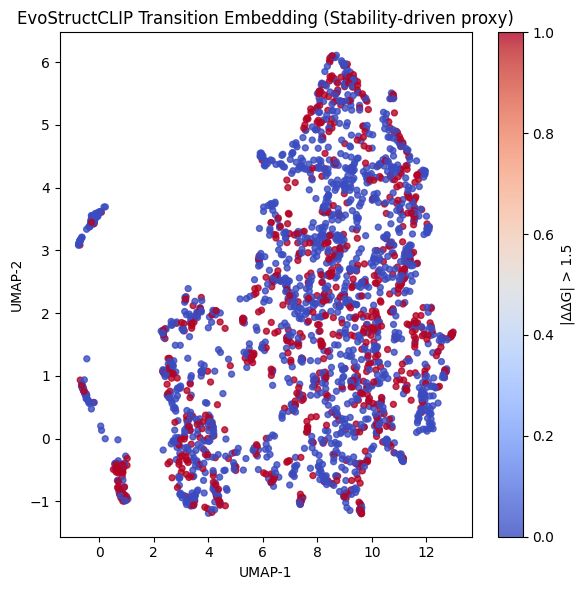

In [16]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42
)

Z_2d = reducer.fit_transform(X_msa)

plt.figure(figsize=(6, 6))
scatter = plt.scatter(
    Z_2d[:, 0],
    Z_2d[:, 1],
    c=df["stability_proxy"],
    cmap="coolwarm",
    s=18,
    alpha=0.8
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("EvoStructCLIP Transition Embedding (Stability-driven proxy)")
plt.colorbar(scatter, label="|ΔΔG| > 1.5")
plt.tight_layout()
plt.show()
